# LA Museum Visitors

Individual visits to El Pueblo museums, per month.

*The Museum of Social Justice is an independently operated museum, and reopened to the public May 2021. All El Pueblo-operated museums partially reopened June 10, 2021.

## Load the data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
# from sklearn.preprocessing import StandardScaler
# from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
file_path = "" # REPLACE
df = pd.read_csv(file_path)

In [ ]:
df.head()

,Month,America Tropical Interpretive Center,Avila Adobe,Chinese American Museum,Gateway to Nature Center,Firehouse Museum,Hellman Quon,IAMLA,Pico House,Visitor Center/ El Tranquilo Gallery,Museum of Social Justice,Biscailuz Gallery/ PK Outdoor Exhibit
0,Jan 2014,6602,24778,1581,NaN,4486,0.0,NaN,2204.0,2961.0,NaN,NaN
1,Feb 2014,5029,18976,1785,NaN,4172,0.0,NaN,1330.0,2276.0,NaN,NaN
2,Mar 2014,8129,25231,3229,NaN,7082,70.0,NaN,4320.0,3116.0,NaN,NaN
3,Apr 2014,2824,26989,2129,NaN,6756,250.0,NaN,3277.0,2808.0,NaN,NaN
4,May 2014,10694,36883,3676,NaN,10858,135.0,NaN,4122.0,3987.0,NaN,NaN


## Data Cleaning

In [ ]:
# Sum visitors across all museums for each month
df['Total Visitors'] = df.drop(['Month'], axis=1).sum(axis=1)

In [ ]:
# Create a datetime column
df['Date'] = pd.to_datetime(df['Month'], format='%b %Y')

In [ ]:
# Replace NaN values with 0
df = df.fillna(0)

In [ ]:
df.head()

,Month,America Tropical Interpretive Center,Avila Adobe,Chinese American Museum,Gateway to Nature Center,Firehouse Museum,Hellman Quon,IAMLA,Pico House,Visitor Center/ El Tranquilo Gallery,Museum of Social Justice,Biscailuz Gallery/ PK Outdoor Exhibit,Total Visitors,Date
0,Jan 2014,6602,24778,1581,0.0,4486,0.0,0.0,2204.0,2961.0,0.0,0.0,42612.0,2014-01-01
1,Feb 2014,5029,18976,1785,0.0,4172,0.0,0.0,1330.0,2276.0,0.0,0.0,33568.0,2014-02-01
2,Mar 2014,8129,25231,3229,0.0,7082,70.0,0.0,4320.0,3116.0,0.0,0.0,51177.0,2014-03-01
3,Apr 2014,2824,26989,2129,0.0,6756,250.0,0.0,3277.0,2808.0,0.0,0.0,45033.0,2014-04-01
4,May 2014,10694,36883,3676,0.0,10858,135.0,0.0,4122.0,3987.0,0.0,0.0,70355.0,2014-05-01


## Plotting

<Axes: xlabel='Date', ylabel='Total Visitors'>

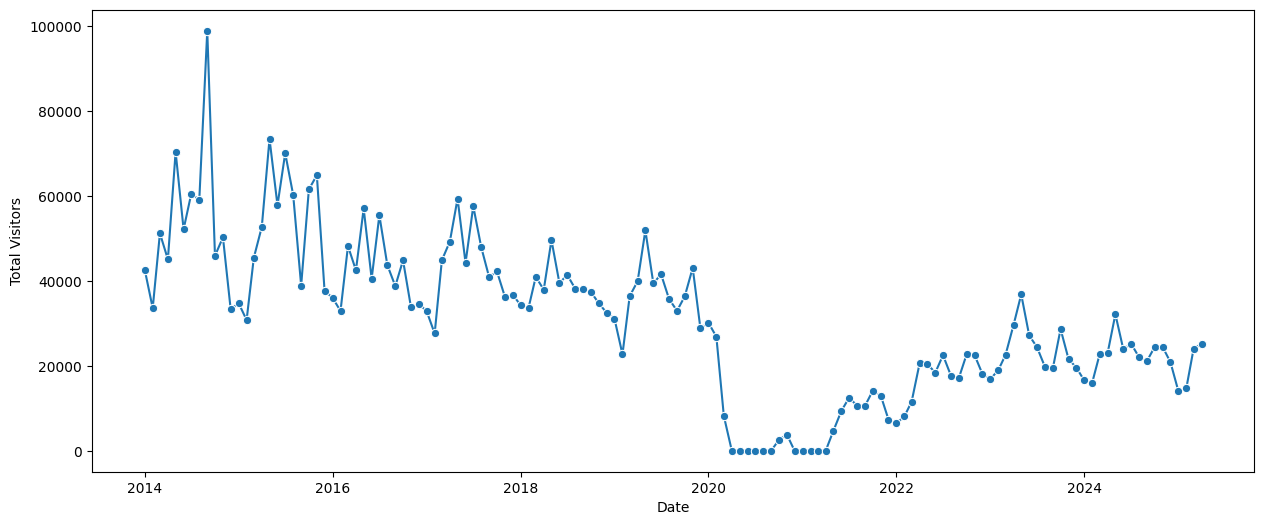

In [ ]:
plt.figure(figsize=(15, 6))
sb.lineplot(data=df, x='Date', y='Total Visitors', marker='o')

In [ ]:
# Compute average monthly visitors for each museum
avg_visitors = df.drop(columns=['Total Visitors', 'Month', 'Date']).mean().sort_values(ascending=False).reset_index()
avg_visitors.rename(columns={'index':'Museum', 0:'Average Monthly Visitors'}, inplace=True)

<Axes: xlabel='Average Monthly Visitors', ylabel='Museum'>

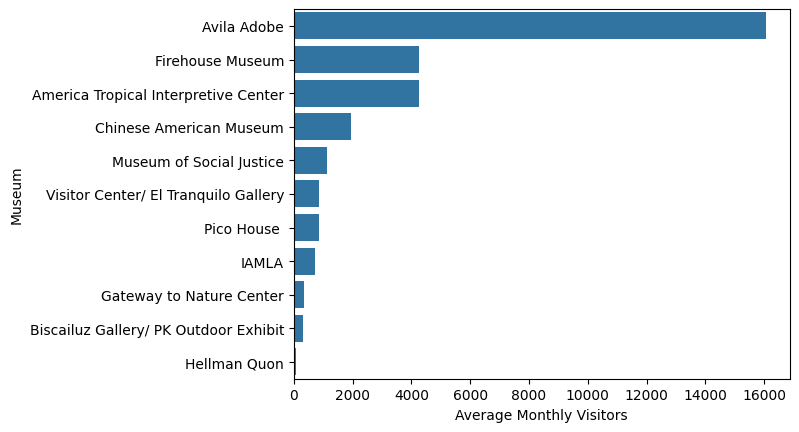

In [ ]:
sb.barplot(x=avg_visitors['Average Monthly Visitors'], y=avg_visitors['Museum'])

In [ ]:
# # Transpose so rows = museums, columns = months
# df_museums = df.drop(columns=['Total Visitors', 'Month', 'Date']).dropna().T

# # Normalize visitation patterns across months
# scaler = StandardScaler()
# scaled = scaler.fit_transform(df_museums)

# # Hierarchical clustering
# linked = linkage(scaled, method='ward')

# # Dendrogram
# plt.figure(figsize=(12, 6))
# dendrogram(linked, labels=df_museums.index, orientation='right')
# plt.title('Museum Clustering Based on Visitation Patterns')
# plt.tight_layout()
# plt.show()